# 第8课 · 🎨 让旋转看得见——复数平面（complex plane）上的单位圆（unit circle）、共轭（conjugate）与相位（phase）

配合 L04–L07 的图形化分册。`xviz` 工具包，统一配色，中文自动适配。

**目标**：用 `matplotlib` 把单位圆旋转、共轭（complex conjugate）和相位（phase）画出来，建立"复数乘法 = 旋转"的空间直觉。

**为什么对 Aurora 重要**：DFT 的旋转因子 `e^{−2πikn/N}` 在复数平面上就是单位圆上的旋转；看懂这张图，L37–L39 重写 FFT 时旋转因子就不抽象。

← **上一课**　[L07 · 万物皆正弦](L07_fourier_intuition.ipynb)

> 上节课学习了 **万物皆正弦**：用三角波叠加合成方波，傅里叶直觉一图彻底建立。  
> 本课将探讨 **复数平面可视化**。

## 本课剧情：让旋转变得可见

数学公式很精确，但有时候你需要**看见**它才能真正理解。

e^{iθ} = cosθ + i·sinθ 是欧拉公式。但只读公式，很多人只记住了符号——没有建立起"复数 = 圆上的点，乘法 = 旋转"的直觉。

本课是纯可视化课：**同一个概念，用图说话**。

你将看到：
- 单位圆旋转 → 正弦波是它的"侧影"（L04/L06 复现）
- 正弦三要素 → 振幅、频率、相位三个参数各自怎么改变波形（L04）
- 复数的模和相位 → 箭头的长度和方向（L05）
- 单位根 → DFT 旋转因子均匀分布在圆上（L06/L37）
- 方波叠加 → 项数越多边缘越陡（L07）

本课唯一的练习：实现 `plot_conjugate(z)` — 画出 z 和其共轭 z̄ 在复数平面上的对称关系。

In [1]:
try:
    from xviz import (style, unit_circle_euler, sinusoid_anatomy,
                      complex_point, roots_of_unity, fourier_square)
    style()
    print('xviz 就绪')
except ImportError:
    import numpy as np
    import matplotlib.pyplot as plt
    import aurora.aviz as _aviz

    def unit_circle_euler(theta):
        """单位圆上角度 theta 对应的点，含坐标标注。"""
        fig, ax = plt.subplots(figsize=(5, 5))
        t_full = np.linspace(0, 2*np.pi, 300)
        ax.plot(np.cos(t_full), np.sin(t_full), 'k-', lw=1, alpha=0.3)
        ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
        z = np.exp(1j * theta)
        ax.plot([0, z.real], [0, z.imag], '#2A9D8F', lw=2)
        ax.scatter([z.real], [z.imag], color='#E76F51', s=80, zorder=5)
        ax.annotate(f'  (cos θ, sin θ)\n= ({z.real:.3f}, {z.imag:.3f})',
                    xy=(z.real, z.imag), fontsize=10)
        ax.set_aspect('equal'); ax.set_title(f'e^{{iθ}}，θ = {theta:.3f} rad')
        plt.tight_layout(); plt.show()

    def sinusoid_anatomy():
        """正弦波三要素：振幅、频率、相位。"""
        t = np.linspace(0, 2, 500)
        fig, ax = plt.subplots(figsize=(10, 3))
        y = 1.5 * np.sin(2*np.pi*2*t + np.pi/4)
        ax.plot(t, y, '#2A9D8F', lw=2)
        ax.axhline(0, color='k', lw=0.5)
        ax.annotate('振幅 A=1.5', xy=(0.15, 1.5), fontsize=10, color='#E76F51')
        ax.annotate('周期 T=0.5s → f=2Hz', xy=(0.9, 0.2), fontsize=10, color='#264653')
        ax.set_title('正弦波三要素：A·sin(2πft + φ)'); plt.tight_layout(); plt.show()

    def complex_point(z):
        """复数 z 在复数平面上的表示。"""
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
        ax.plot([0, z.real], [0, z.imag], '#2A9D8F', lw=2)
        ax.scatter([z.real], [z.imag], color='#E76F51', s=80, zorder=5)
        ax.annotate(f'  {z.real:+.1f}{z.imag:+.1f}j\n  |z|={abs(z):.2f}, ∠={np.degrees(np.angle(z)):.1f}°',
                    xy=(z.real, z.imag), fontsize=10)
        lim = abs(z) * 1.4
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_aspect('equal'); ax.set_title(f'复数平面：z = {z}')
        plt.tight_layout(); plt.show()

    def roots_of_unity(N):
        """N 个单位根 = DFT 旋转因子。"""
        _aviz.twiddles(N)

    def fourier_square(ns):
        """傅里叶级数近似方波。"""
        t = np.linspace(0, 1, 1000)
        fig, ax = plt.subplots(figsize=(10, 4))
        for n in ns:
            y = sum(np.sin(2*np.pi*k*t)/k for k in range(1, n+1, 2)) * 4/np.pi
            ax.plot(t, y, label=f'{n} harmonics', alpha=0.7)
        ax.legend(); ax.set_title('傅里叶级数近似方波')
        plt.tight_layout(); plt.show()

    print('⚠️  xviz 未安装，已切换到 aurora.aviz 替代实现（功能等价）')

xviz 就绪


## 实验入口：角度、坐标和旋转

`z = np.exp(1j * angles)` 对角度数组一次性返回实部（cos）和虚部（sin）。运行时注意 `z.real` 和 `z.imag` 如何随角度交替升降。

## 动手观察：复数就是"旋转的位置"

复数三角的关键不是符号多，而是它把二维平面上的旋转写成一个数。下面先看几个角度对应的复数坐标。

In [ ]:
import numpy as np

angles = np.array([0, np.pi/2, np.pi, 3*np.pi/2])
z = np.exp(1j * angles)

print('角度 =', np.round(angles, 3))
print('实部 cos =', np.round(z.real, 3))
print('虚部 sin =', np.round(z.imag, 3))
print('复数 z =', np.round(z, 3))


## 代码实验：旋转一整圈

把 `2π` 均分成 8 段，验证 `exp(1j*theta)` 的坐标按 cos/sin 规律落在单位圆上。

In [ ]:
import numpy as np

for k in range(9):
    theta = 2 * np.pi * k / 8
    z = np.exp(1j * theta)
    print(f'k={k} theta={theta:.2f} -> ({z.real:+.3f}, {z.imag:+.3f})')


## 1. 欧拉公式：e^{iθ} 是单位圆上的旋转（对应 L06）

`e^{iθ}` 的实部是 `cos θ`，虚部是 `sin θ`——角度 θ 从 0 扫到 2π，对应的点沿单位圆走满一整圈。复数乘法在平面上等价于旋转：两个复数相乘，模（magnitude，r）相乘、幅角相加，这正是欧拉公式的几何含义。

本视觉分册把正弦三要素（L04）、复数模相位（L05）、欧拉公式（L06）、傅里叶叠加（L07）四节的核心图形统一放在 `xviz` 配色体系下呈现，让正弦波（sinusoid / sine wave）的升降与旋转向量的投影同框可见，而不必在四个独立文件间反复跳转才能看到它们的关联。

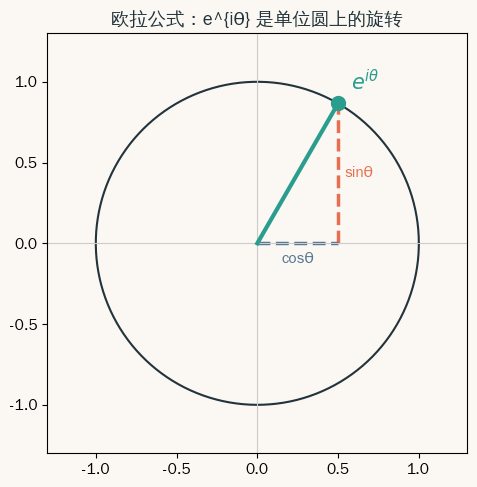

In [2]:
import numpy as np
unit_circle_euler(np.pi/3);

## 2. 正弦三要素：振幅（amplitude） / 频率（frequency） / 相位（对应 L04）

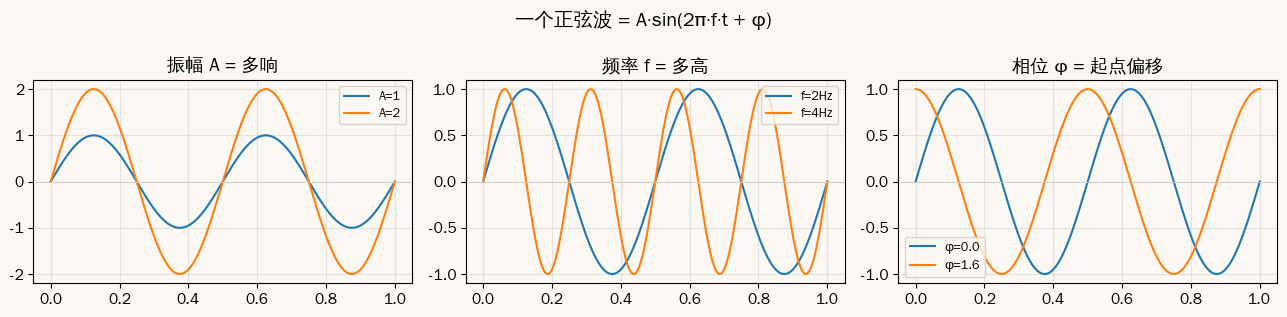

In [3]:
sinusoid_anatomy();

## 3. 复数 = 平面上的点：模 + 相位（对应 L05）

**🔗 Aurora**：`src/aurora/audio/transforms.py` 的 FFT 输出是复数数组；对它取 `np.abs()` 得到幅度谱（该频率的能量强度），取 `np.angle()` 得到相位谱（信号在该频率上的时间对齐）。`notebooks/1_complex_trig/L06_euler.ipynb` 的 `twiddle(k, n, N)` 每个值就是一个落在单位圆上的旋转因子——固定频率索引 k、让 n 扫过 0..N-1 得到的一列旋转因子，与输入信号做内积后返回的就是对应频点（frequency bin）的复数结果。

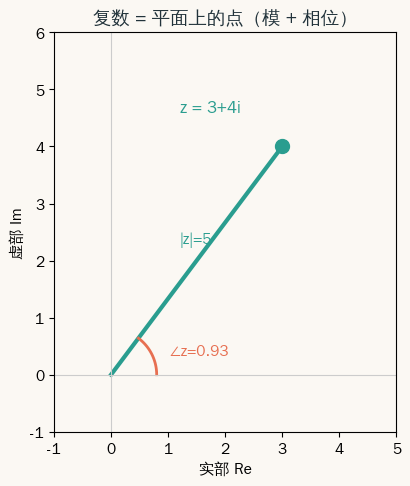

In [4]:
complex_point(3+4j);

## 3b. 复数共轭（complex conjugate）：实轴对称的反射

复数 `z = a + bj` 的共轭（conjugate）是 `z̄ = a − bj`：把虚部取反，几何上等价于把点关于实轴做镜像反射（reflection across the real axis）。

**性质验证**：
- `z + z̄ = 2a`（两倍实部，虚部消去）
- `z × z̄ = a² + b² = |z|²`（模的平方，纯实数）

**Aurora 连接**：实值信号的 DFT 满足共轭对称性（conjugate symmetry）`X[N−k] = conj(X[k])`，因此只需存储前半段频谱，这是 `src/aurora/audio/transforms.py` FFT 输出的压缩基础。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_conjugate_demo(z):
    """演示：复数 z 与其共轭 z̄ 在复数平面上的对称关系。"""
    z_conj = z.conjugate()
    fig, ax = plt.subplots(figsize=(5, 5))
    t = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(t)*abs(z), np.sin(t)*abs(z), 'gray', lw=0.5, alpha=0.3, ls='--')
    ax.axhline(0, color='k', lw=0.8)
    ax.axvline(0, color='k', lw=0.5)
    # z
    ax.plot([0, z.real], [0, z.imag], '#2A9D8F', lw=2)
    ax.scatter([z.real], [z.imag], color='#2A9D8F', s=80, zorder=5,
               label=f'z = {z.real:+.2f}{z.imag:+.2f}j')
    # z̄
    ax.plot([0, z_conj.real], [0, z_conj.imag], '#E76F51', lw=2, ls='--')
    ax.scatter([z_conj.real], [z_conj.imag], color='#E76F51', s=80, zorder=5,
               label=f'z̄ = {z_conj.real:+.2f}{z_conj.imag:+.2f}j')
    ax.set_aspect('equal')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_title(f'共轭对称  |z| = |z̄| = {abs(z):.2f}   z×z̄ = {(z*z_conj):.2f}')
    plt.tight_layout(); plt.show()

    print(f'z          = {z}')
    print(f'z̄ (共轭)   = {z_conj}')
    print(f'z + z̄      = {z + z_conj:.3f}  → 应为 2×实部 = {2*z.real:.3f}')
    print(f'z × z̄      = {(z * z_conj).real:.3f}  → 应为 |z|² = {abs(z)**2:.3f}')
    print(f'z̄.imag == -z.imag: {z_conj.imag == -z.imag}')

plot_conjugate_demo(3 + 4j)

## 🏋️ 练习：实现 plot_conjugate

**任务**：补全下方函数，在同一坐标轴上画出 `z` 和 `z̄`，并在图标题中显示两者的模。

**三个验证点**：
1. `z.conjugate().imag == −z.imag`（虚部取反）
2. `abs(z) == abs(z.conjugate())`（模不变）
3. `(z * z.conjugate()).imag ≈ 0`（乘积为纯实数）

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_conjugate(z):
    """在同一坐标轴上画出 z 和 z̄，图标题显示两者的模。"""
    # ✏️ TODO:
    #   1. 计算共轭: z_conj = z.real - 1j * z.imag
    #   2. 计算模: mag = abs(z)
    #   3. fig, ax = plt.subplots()
    #   4. 用 ax.annotate 或 ax.quiver 画出 z 和 z_conj 的箭头
    #   5. ax.set_title(f'|z| = {mag:.2f}')
    raise NotImplementedError("TODO: 实现 plot_conjugate")

# ── 完成函数后取消下面注释 ──
# plot_conjugate(3 + 4j)
# plot_conjugate(1 + 1j)
# plot_conjugate(-2 + 3j)

# ── 自动断言（函数实现后运行即可验证）──
z_test = 3 + 4j
z_bar  = z_test.conjugate()
try:
    plot_conjugate(z_test)
    assert z_bar.imag == -z_test.imag,       f"虚部取反失败: {z_bar.imag} != {-z_test.imag}"
    assert abs(z_test) == abs(z_bar),         f"模应相等: {abs(z_test)} != {abs(z_bar)}"
    assert abs((z_test * z_bar).imag) < 1e-10, f"z×z̄ 应为纯实数，虚部 = {(z_test * z_bar).imag}"
    print("✅ 所有断言通过")
except NotImplementedError:
    print("⏳ 请先实现 plot_conjugate(z)，再运行断言。")

In [ ]:
# 共轭的数学性质（验证公式，不是白板答案格）
# 验证 plot_conjugate 的数学属性（不需要真正调用绘图）
import numpy as np

# 共轭的属性：实部相同，虚部相反，模相等
z = 3 + 4j
z_conj = z.real - 1j * z.imag
assert z_conj == (3 - 4j),            f"共轭应为 3-4j，得到 {z_conj}"
assert abs(z_conj) == abs(z),          f"模应相等：|z|={abs(z)}, |z̄|={abs(z_conj)}"
assert np.isclose(z * z_conj, abs(z)**2), f"z·z̄ = |z|² 应为 {abs(z)**2}"
print(f"共轭验证 ✅")
print(f"  z     = {z}  |z| = {abs(z)}")
print(f"  z̄     = {z_conj}  |z̄| = {abs(z_conj)}")
print(f"  z·z̄   = {z * z_conj:.1f}  = |z|² = {abs(z)**2:.1f}")
print("  结论：共轭不改变模，只翻转虚部符号（关于实轴对称）")

## 4. 单位根 = DFT 的旋转因子（对应 L06 / L37-L39 的 FFT）

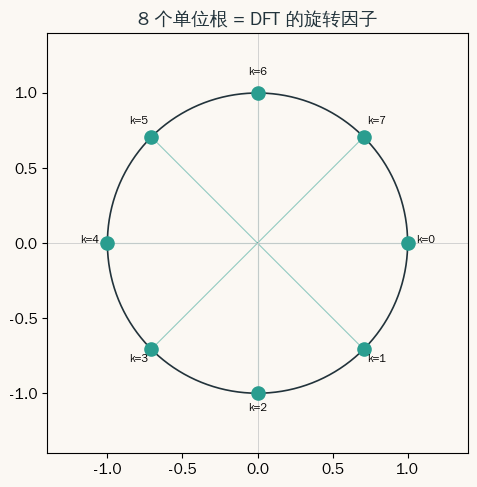

In [5]:
roots_of_unity(8);

## 5. 正弦叠加 → 方波（square wave）：傅里叶级数（Fourier series）直觉（对应 L07）

**🔗 Aurora**：`fourier_square((1,3,9,50))` 用奇次谐波（odd harmonics）叠加逼近方波——这正是傅里叶级数的截断近似。`notebooks/1_complex_trig/L06_euler.ipynb` 的 `twiddle(k, n, N)` 把同样的分解推广到任意离散信号：FFT 做的就是高效计算信号在每个频率分量上的投影系数，逆变换则是把这些分量叠加还原。

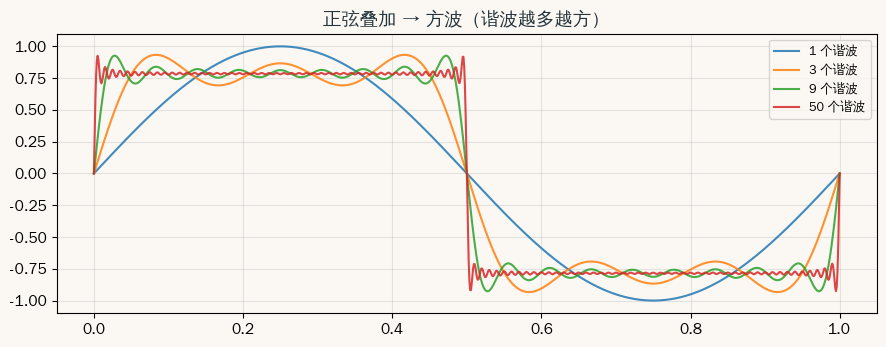

In [6]:
fourier_square((1,3,9,50));

In [ ]:
for k in range(8):
    theta = 2*np.pi*k/8
    z = np.exp(1j*theta)
    radius = abs(z)
    print(f'k={k} | z=({z.real:+.2f}, {z.imag:+.2f}) | 半径={radius:.2f}')
print('所有点半径都接近 1，说明它们都在单位圆上。')


## 参数实验：改变单位根数量

在第 4 节（单位根图）中，把 `roots_of_unity(8)` 的参数 `N` 从 `8` 改到 `16`，观察旋转因子从 8 个变成 16 个，均匀分布在单位圆上的密度如何翻倍，相邻点的角度间隔从 `2π/8 = 45°` 缩减到 `2π/16 = 22.5°`。无论 N 取何值，每个单位根 `W_N^k = e^{-i2πk/N}` 的 `abs(z)` 始终为 1，这保证了 DFT 矩阵的列向量是等模的旋转基。

## 本课收束

现在可以调用 `unit_circle_euler(theta)` 可视化单位圆上的任意旋转角，用 `roots_of_unity(N)` 生成 DFT 需要的 N 个旋转因子 `W_N^k = e^{-i2πk/N}`。这组等间距复数点的半径恒为 1，是 FFT 蝶形运算（butterfly operation）的几何来源。L06 的旋转因子几何（`twiddle`）与本课单位根一致；L37–L39 会手写 FFT / DFT 矩阵。L37-L41 频谱（spectrum）图（spectrogram）里每个频点的复数输出，就是信号与对应单位根做点积的结果。

下一课进入线性代数（L09），从向量（vector）空间和矩阵（matrix）乘法出发，为 DFT 矩阵形式奠定基础。

In [ ]:
# ✏️ 本课自评
l08_review = {
    "plot_conjugate_done":    None,  # plot_conjugate 实现并通过断言？True/False
    "unit_circle_intuition":  None,  # 能把 e^{iθ} 与单位圆旋转对应？True/False
    "twiddle_geometry":       None,  # 能解释单位根与 L06 twiddle 的关系？True/False
    "conjugate_properties_verified": None,  # 共轭三性质（虚部取反/模不变/z·z̄ 纯实数）验证通过？True/False
}

unfilled = [k for k, v in l08_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l08_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L08 全部通关！进入 L09：向量基础')


---

→ **下一课**　[L09 · 向量代数](../2_linear_algebra/L09_vectors.ipynb)

> 下节课将学习 **向量代数**：加法、标量乘法与线性组合，NumPy 实现 + 几何意义。